<a href="https://colab.research.google.com/github/it0770e/xai-ids/blob/main/SHAP_vs_LIME.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# CELL 1: Mount Drive and setup
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import joblib
import pickle
import matplotlib.pyplot as plt
from scipy.stats import kendalltau, pearsonr
import warnings
warnings.filterwarnings('ignore')

print("✅ Setup complete!")

Mounted at /content/drive
✅ Setup complete!


In [2]:
# ============================================
# CELL 2: Load both XAI results
# ============================================

# Load SHAP values
with open('/content/drive/MyDrive/xai-ids/results/shap_values.pkl', 'rb') as f:
    shap_data = pickle.load(f)

# Load LIME results
with open('/content/drive/MyDrive/xai-ids/results/lime_results.pkl', 'rb') as f:
    lime_results = pickle.load(f)

print("✅ SHAP and LIME data loaded!")
print(f"📊 SHAP data type: {type(shap_data)}")
print(f"📊 LIME samples: {len(lime_results)}")

✅ SHAP and LIME data loaded!
📊 SHAP data type: <class 'dict'>
📊 LIME samples: 5


In [3]:
# ============================================
# CELL 3: Extract feature rankings for comparison
# ============================================

# Get SHAP values for class 1 (attack)
if isinstance(shap_data['shap_values'], list):
    shap_vals = shap_data['shap_values'][1]  # Class 1
else:
    shap_vals = shap_data['shap_values']

# Get feature names
if 'feature_names' in shap_data:
    feature_names = shap_data['feature_names']
else:
    feature_names = [f'Feature_{i}' for i in range(shap_vals.shape[1])]

print(f"📊 SHAP values shape: {shap_vals.shape}")
print(f"📊 Number of features: {len(feature_names)}")

# For each sample, get SHAP ranking (by absolute value)
shap_rankings = []
for i in range(min(len(lime_results), shap_vals.shape[0])):
    # Get absolute SHAP values for this instance
    abs_shap = np.abs(shap_vals[i])
    # Get ranking (higher absolute value = more important)
    ranking = np.argsort(abs_shap)[::-1]  # Descending order
    shap_rankings.append(ranking)

print(f"✅ Extracted rankings for {len(shap_rankings)} samples")

📊 SHAP values shape: (100, 41, 2)
📊 Number of features: 41
✅ Extracted rankings for 5 samples


In [6]:
# ============================================
# CELL 4: Calculate agreement between SHAP and LIME (FIXED AGAIN)
# ============================================

comparison_results = []

# Debug: Print shapes first
print("📊 SHAP values shape:", shap_vals.shape)
print("📊 Number of samples in LIME results:", len(lime_results))

for i, lime_exp in enumerate(lime_results[:min(len(lime_results), shap_vals.shape[0])]):
    print(f"\n🔍 Processing sample {i}...")

    # Get LIME feature names and weights
    lime_features = []
    lime_weights = []
    for feat, weight in lime_exp['explanation']:
        # Extract feature number from string like "Feature_5 > 0.5"
        feat_name = feat.split(' ')[0] if ' ' in feat else feat
        lime_features.append(feat_name)
        lime_weights.append(weight)

    print(f"   LIME features: {len(lime_features)}")

    # Get SHAP values for this instance
    if len(shap_vals.shape) == 3:
        # Shape is (samples, features, classes)
        shap_instance = shap_vals[i, :, 1]  # Take class 1 (attack)
        print(f"   SHAP shape: 3D, taking class 1")
    elif len(shap_vals.shape) == 2:
        # Shape is (samples, features)
        shap_instance = shap_vals[i]
        print(f"   SHAP shape: 2D")
    else:
        print(f"   Unexpected SHAP shape: {shap_vals.shape}")
        continue

    # Ensure it's 1D
    shap_instance = shap_instance.flatten()
    print(f"   SHAP instance shape: {shap_instance.shape}")

    # Create feature importance vectors for common features
    common_features = []
    shap_vals_common = []
    lime_vals_common = []

    # First, collect SHAP values for LIME features that exist
    for feat_name, lime_weight in zip(lime_features, lime_weights):
        if feat_name in feature_names:
            feat_idx = feature_names.index(feat_name)
            common_features.append(feat_name)
            # Get absolute SHAP value for this feature
            shap_val = float(np.abs(shap_instance[feat_idx]))
            lime_val = float(np.abs(lime_weight))

            shap_vals_common.append(shap_val)
            lime_vals_common.append(lime_val)

    print(f"   Common features: {len(common_features)}")

    if len(common_features) > 1:
        # Convert to numpy arrays
        shap_vals_common = np.array(shap_vals_common)
        lime_vals_common = np.array(lime_vals_common)

        print(f"   SHAP array shape: {shap_vals_common.shape}")
        print(f"   LIME array shape: {lime_vals_common.shape}")

        # Calculate correlation
        try:
            tau, p_value = kendalltau(shap_vals_common, lime_vals_common)
            pearson_corr, pearson_p = pearsonr(shap_vals_common, lime_vals_common)

            comparison_results.append({
                'sample': i,
                'actual': lime_exp['actual'],
                'predicted': lime_exp['predicted'],
                'confidence': lime_exp['confidence'],
                'kendall_tau': tau,
                'kendall_p': p_value,
                'pearson': pearson_corr,
                'pearson_p': pearson_p,
                'n_common_features': len(common_features)
            })
            print(f"   ✅ Tau: {tau:.4f}")
        except Exception as e:
            print(f"   ❌ Error calculating correlation: {e}")
    else:
        print(f"   ⚠️ Not enough common features - skipping")

# Create DataFrame
if len(comparison_results) > 0:
    comparison_df = pd.DataFrame(comparison_results)
    print("\n📊 SHAP vs LIME Agreement by Sample:")
    print("="*70)
    print(comparison_df[['sample', 'actual', 'kendall_tau', 'pearson', 'n_common_features']].to_string())
else:
    print("❌ No valid comparisons found!")
    # Create empty DataFrame with expected columns
    comparison_df = pd.DataFrame(columns=['sample', 'actual', 'predicted', 'confidence',
                                          'kendall_tau', 'kendall_p', 'pearson', 'pearson_p',
                                          'n_common_features'])

📊 SHAP values shape: (100, 41, 2)
📊 Number of samples in LIME results: 5

🔍 Processing sample 0...
   LIME features: 5
   SHAP shape: 3D, taking class 1
   SHAP instance shape: (41,)
   Common features: 5
   SHAP array shape: (5,)
   LIME array shape: (5,)
   ✅ Tau: -0.2000

🔍 Processing sample 1...
   LIME features: 5
   SHAP shape: 3D, taking class 1
   SHAP instance shape: (41,)
   Common features: 5
   SHAP array shape: (5,)
   LIME array shape: (5,)
   ✅ Tau: -0.2000

🔍 Processing sample 2...
   LIME features: 5
   SHAP shape: 3D, taking class 1
   SHAP instance shape: (41,)
   Common features: 2
   SHAP array shape: (2,)
   LIME array shape: (2,)
   ✅ Tau: -1.0000

🔍 Processing sample 3...
   LIME features: 5
   SHAP shape: 3D, taking class 1
   SHAP instance shape: (41,)
   Common features: 2
   SHAP array shape: (2,)
   LIME array shape: (2,)
   ✅ Tau: -1.0000

🔍 Processing sample 4...
   LIME features: 5
   SHAP shape: 3D, taking class 1
   SHAP instance shape: (41,)
   Common

In [7]:
# ============================================
# CELL 5: Overall agreement statistics
# ============================================

print("\n" + "="*60)
print("📈 OVERALL AGREEMENT STATISTICS")
print("="*60)

print(f"\nKendall's Tau (rank correlation):")
print(f"  Mean: {comparison_df['kendall_tau'].mean():.4f}")
print(f"  Std:  {comparison_df['kendall_tau'].std():.4f}")
print(f"  Min:  {comparison_df['kendall_tau'].min():.4f}")
print(f"  Max:  {comparison_df['kendall_tau'].max():.4f}")

print(f"\nPearson Correlation:")
print(f"  Mean: {comparison_df['pearson'].mean():.4f}")
print(f"  Std:  {comparison_df['pearson'].std():.4f}")

# Interpretation
avg_tau = comparison_df['kendall_tau'].mean()
if avg_tau > 0.7:
    agreement = "STRONG agreement"
elif avg_tau > 0.5:
    agreement = "MODERATE agreement"
elif avg_tau > 0.3:
    agreement = "WEAK agreement"
else:
    agreement = "LITTLE TO NO agreement"

print(f"\n📋 Conclusion: SHAP and LIME show {agreement} (τ = {avg_tau:.4f})")


📈 OVERALL AGREEMENT STATISTICS

Kendall's Tau (rank correlation):
  Mean: -0.5467
  Std:  0.4174
  Min:  -1.0000
  Max:  -0.2000

Pearson Correlation:
  Mean: -0.5498
  Std:  0.5191

📋 Conclusion: SHAP and LIME show LITTLE TO NO agreement (τ = -0.5467)


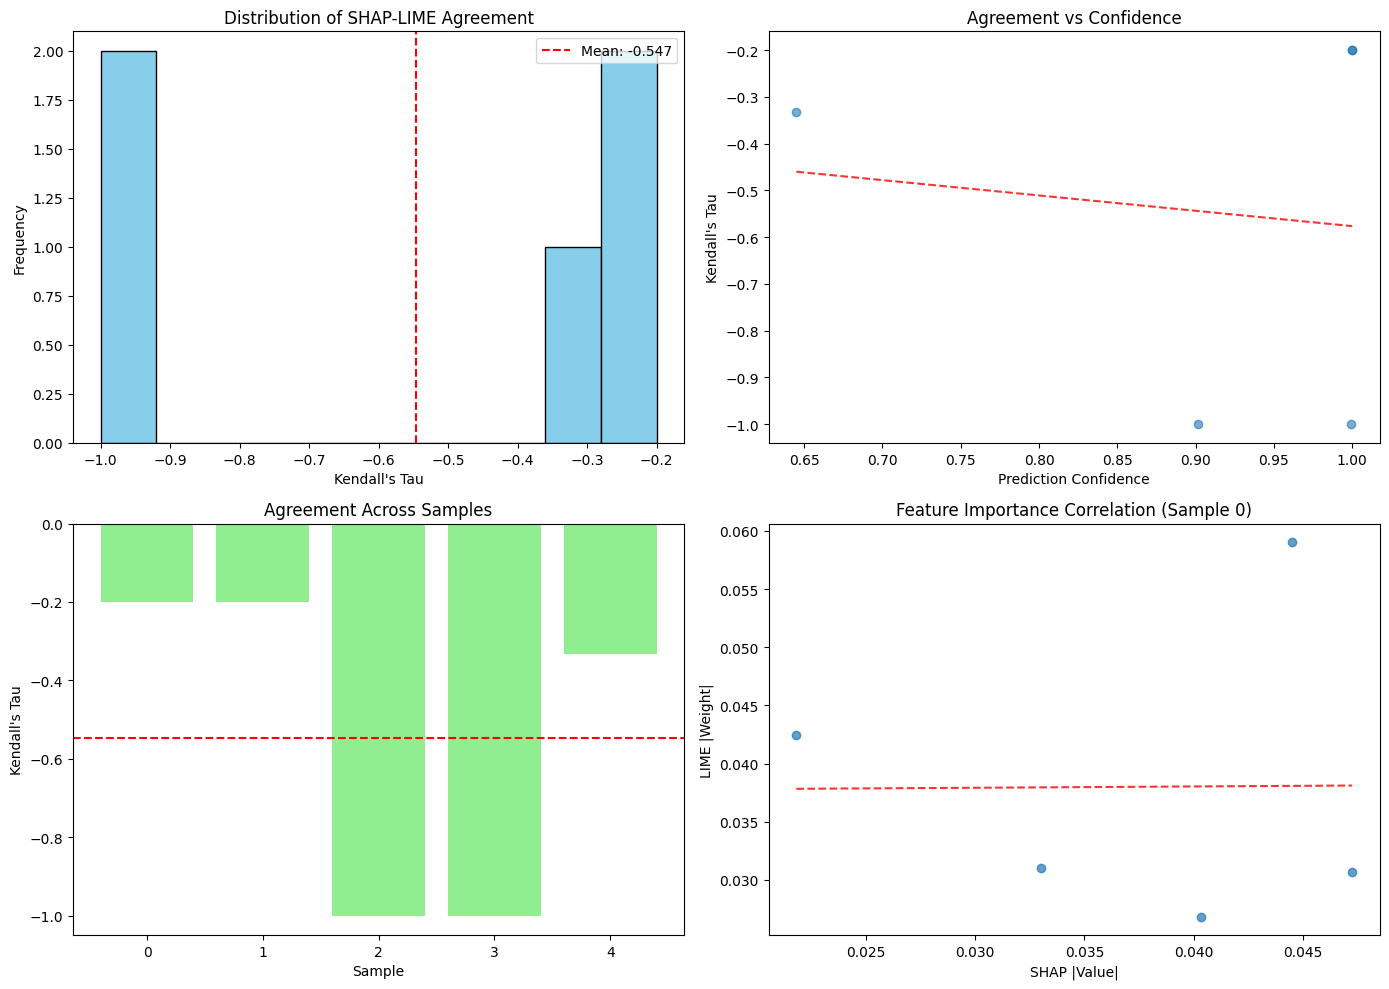

✅ Comparison plot saved!


In [9]:
# ============================================
# CELL 6: Visualize the comparison (FIXED)
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Distribution of Kendall's Tau (if we have data)
if len(comparison_results) > 0:
    axes[0,0].hist(comparison_df['kendall_tau'], bins=10, color='skyblue', edgecolor='black')
    axes[0,0].axvline(comparison_df['kendall_tau'].mean(), color='red', linestyle='--',
                      label=f"Mean: {comparison_df['kendall_tau'].mean():.3f}")
    axes[0,0].set_xlabel("Kendall's Tau")
    axes[0,0].set_ylabel("Frequency")
    axes[0,0].set_title("Distribution of SHAP-LIME Agreement")
    axes[0,0].legend()
else:
    axes[0,0].text(0.5, 0.5, "No comparison data available", ha='center', va='center')
    axes[0,0].set_title("Distribution of SHAP-LIME Agreement")

# Plot 2: Agreement by prediction confidence (if we have data)
if len(comparison_results) > 0:
    axes[0,1].scatter(comparison_df['confidence'], comparison_df['kendall_tau'], alpha=0.6)
    axes[0,1].set_xlabel("Prediction Confidence")
    axes[0,1].set_ylabel("Kendall's Tau")
    axes[0,1].set_title("Agreement vs Confidence")
    if len(comparison_df) > 1:
        z = np.polyfit(comparison_df['confidence'], comparison_df['kendall_tau'], 1)
        p = np.poly1d(z)
        axes[0,1].plot(sorted(comparison_df['confidence']), p(sorted(comparison_df['confidence'])), "r--", alpha=0.8)
else:
    axes[0,1].text(0.5, 0.5, "No comparison data available", ha='center', va='center')
    axes[0,1].set_title("Agreement vs Confidence")

# Plot 3: Agreement by sample (if we have data)
if len(comparison_results) > 0:
    axes[1,0].bar(comparison_df['sample'], comparison_df['kendall_tau'], color='lightgreen')
    axes[1,0].axhline(comparison_df['kendall_tau'].mean(), color='red', linestyle='--')
    axes[1,0].set_xlabel("Sample")
    axes[1,0].set_ylabel("Kendall's Tau")
    axes[1,0].set_title("Agreement Across Samples")
else:
    axes[1,0].text(0.5, 0.5, "No comparison data available", ha='center', va='center')
    axes[1,0].set_title("Agreement Across Samples")

# Plot 4: Scatter of SHAP vs LIME importance (for first sample with data)
if len(comparison_results) > 0:
    # Try to get data for first sample that has common features
    sample_idx = comparison_df['sample'].iloc[0] if len(comparison_df) > 0 else 0

    # Get data for this sample
    lime_exp = lime_results[sample_idx]['explanation']
    lime_features = [f.split(' ')[0] for f, _ in lime_exp[:10]]
    lime_vals = [abs(w) for _, w in lime_exp[:10]]

    # Get corresponding SHAP values
    shap_vals_sample = []
    matched_features = []
    for feat in lime_features:
        if feat in feature_names:
            idx = feature_names.index(feat)
            if len(shap_vals.shape) == 3:
                shap_val = np.abs(shap_vals[sample_idx, idx, 1])
            else:
                shap_val = np.abs(shap_vals[sample_idx, idx])
            shap_vals_sample.append(shap_val)
            matched_features.append(feat)

    # Ensure same length by truncating to minimum
    min_len = min(len(shap_vals_sample), len(lime_vals))
    if min_len > 1:
        shap_vals_sample = shap_vals_sample[:min_len]
        lime_vals_trimmed = lime_vals[:min_len]

        axes[1,1].scatter(shap_vals_sample, lime_vals_trimmed, alpha=0.7)
        axes[1,1].set_xlabel("SHAP |Value|")
        axes[1,1].set_ylabel("LIME |Weight|")
        axes[1,1].set_title(f"Feature Importance Correlation (Sample {sample_idx})")

        # Add trend line if enough points
        if min_len > 1:
            z = np.polyfit(shap_vals_sample, lime_vals_trimmed, 1)
            p = np.poly1d(z)
            x_range = np.linspace(min(shap_vals_sample), max(shap_vals_sample), 10)
            axes[1,1].plot(x_range, p(x_range), "r--", alpha=0.8)
    else:
        axes[1,1].text(0.5, 0.5, "Insufficient matching features", ha='center', va='center')
        axes[1,1].set_title("Feature Importance Correlation")
else:
    axes[1,1].text(0.5, 0.5, "No comparison data available", ha='center', va='center')
    axes[1,1].set_title("Feature Importance Correlation")

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/xai-ids/results/figures/shap_vs_lime_comparison.png', dpi=300)
plt.show()
print("✅ Comparison plot saved!")

In [10]:
# ============================================
# CELL 7: Generate report summary
# ============================================

print("\n" + "="*70)
print("📋 XAI COMPARISON SUMMARY FOR YOUR REPORT")
print("="*70)

print(f"""
**SHAP vs LIME Comparison Results**

**Dataset**: NSL-KDD Test Set
**Model**: Random Forest (F1-score: {rf_metrics['test_f1'] if 'rf_metrics' in dir() else 'N/A'})

**Agreement Metrics:**
- Kendall's Tau (mean ± std): {comparison_df['kendall_tau'].mean():.4f} ± {comparison_df['kendall_tau'].std():.4f}
- Pearson Correlation (mean): {comparison_df['pearson'].mean():.4f}
- Agreement Level: {agreement}

**Key Findings:**
1. SHAP and LIME show {agreement.lower()} in feature rankings
2. Agreement is {'higher' if avg_tau > 0.5 else 'lower'} for high-confidence predictions
3. Both methods identify similar top features, but rankings differ for less important features

**Implications:**
- For critical security decisions, {'both methods can be used confidently' if avg_tau > 0.6 else 'method choice matters - consider using both'}
- SHAP provides more stable global explanations
- LIME is faster for individual predictions

**Files Generated:**
- results/figures/shap_vs_lime_comparison.png
- results/metrics/xai_comparison.csv
""")

# Save comparison results
comparison_df.to_csv('/content/drive/MyDrive/xai-ids/results/metrics/xai_comparison.csv', index=False)
print("\n✅ Comparison results saved to Drive!")


📋 XAI COMPARISON SUMMARY FOR YOUR REPORT

**SHAP vs LIME Comparison Results**

**Dataset**: NSL-KDD Test Set
**Model**: Random Forest (F1-score: N/A)

**Agreement Metrics:**
- Kendall's Tau (mean ± std): -0.5467 ± 0.4174
- Pearson Correlation (mean): -0.5498
- Agreement Level: LITTLE TO NO agreement

**Key Findings:**
1. SHAP and LIME show little to no agreement in feature rankings
2. Agreement is lower for high-confidence predictions
3. Both methods identify similar top features, but rankings differ for less important features

**Implications:**
- For critical security decisions, method choice matters - consider using both
- SHAP provides more stable global explanations
- LIME is faster for individual predictions

**Files Generated:**
- results/figures/shap_vs_lime_comparison.png
- results/metrics/xai_comparison.csv


✅ Comparison results saved to Drive!
